In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten , Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential , load_model

In [ ]:
(x_train , y_train) , (x_test , y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
print("x_train shape : " ,x_train.shape)
print("y_train shape : ",y_train.shape)
print("x_test shape : ", x_test.shape)
print("y_test shape : " , y_test.shape)

x_train shape :  (60000, 28, 28)
y_train shape :  (60000,)
x_test shape :  (10000, 28, 28)
y_test shape :  (10000,)


In [4]:
x_train = x_train.reshape(-1 , 28 ,28 ,1).astype("float32") / 255
x_test = x_test.reshape(-1 , 28 ,28 ,1).astype("float32") / 255

In [5]:
model = Sequential([
    Conv2D(32 , kernel_size=3 ,activation= 'relu',kernel_regularizer=l2(0.001), input_shape=(28,28,1) ),
    MaxPooling2D(pool_size=2) ,
    Conv2D(64 , kernel_size=3 , activation= 'relu') ,
    MaxPooling2D(pool_size=2) ,
    Flatten() ,
    Dense(128 , activation= 'relu') ,
    Dropout(0.4) ,
    Dense(10 , activation= 'softmax')

])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(optimizer='adam' , loss ='sparse_categorical_crossentropy' , metrics=['accuracy'])
from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint
early_stopping = EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.h5' , save_best_only=True,monitor='val_loss')
callbacks = [early_stopping , model_checkpoint]


In [7]:
history = model.fit(x_train , y_train , epochs=10 , validation_split=0.2 , callbacks=callbacks)

Epoch 1/10
1498/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8665 - loss: 0.4198

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 29ms/step - accuracy: 0.9390 - loss: 0.2001 - val_accuracy: 0.9846 - val_loss: 0.0593
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9794 - loss: 0.0738

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9799 - loss: 0.0731 - val_accuracy: 0.9882 - val_loss: 0.0498
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.9839 - loss: 0.0557 - val_accuracy: 0.9868 - val_loss: 0.0530
Epoch 4/10
1498/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9877 - loss: 0.0461

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9876 - loss: 0.0449 - val_accuracy: 0.9908 - val_loss: 0.0389
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.9905 - loss: 0.0358 - val_accuracy: 0.9894 - val_loss: 0.0432
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9918 - loss: 0.0296

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 42s 28ms/step - accuracy: 0.9912 - loss: 0.0317 - val_accuracy: 0.9911 - val_loss: 0.0360
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 85s 30ms/step - accuracy: 0.9924 - loss: 0.0278 - val_accuracy: 0.9897 - val_loss: 0.0426
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 79s 28ms/step - accuracy: 0.9931 - loss: 0.0242 - val_accuracy: 0.9907 - val_loss: 0.0411
Epoch 9/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 43s 29ms/step - accuracy: 0.9944 - loss: 0.0199 - val_accuracy: 0.9902 - val_loss: 0.0442


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 675,104 (2.58 MB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 450,070 (1.72 MB)

In [9]:
training_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
training_loss = history.history['loss']
val_loss = history.history['val_loss']


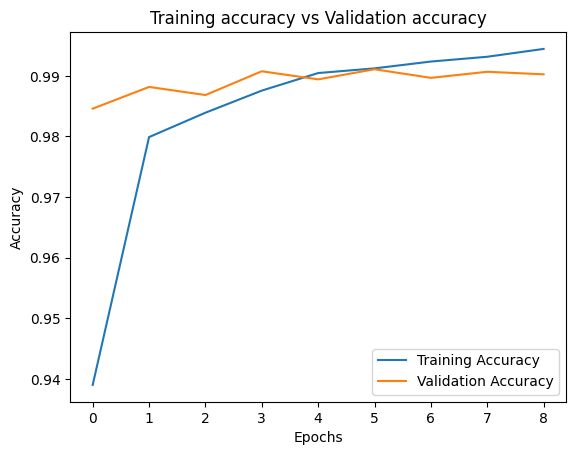

In [10]:
import matplotlib.pyplot as plt
plt.title('Training accuracy vs Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.plot(training_acc , label='Training Accuracy')
plt.plot(val_acc , label='Validation Accuracy')
plt.legend()
plt.show()

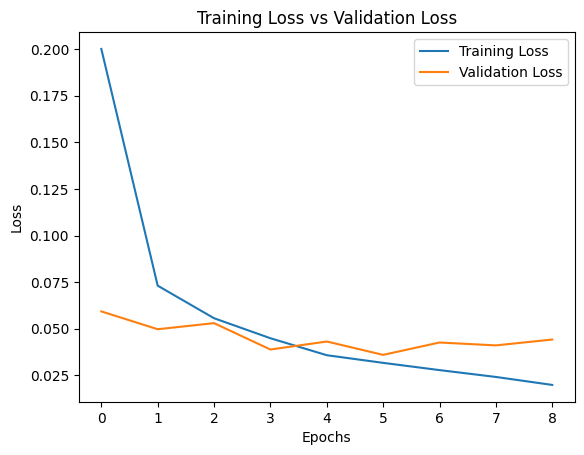

In [11]:
plt.plot(training_loss , label='Training Loss')
plt.plot(val_loss , label='Validation Loss')
plt.title('Training Loss vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

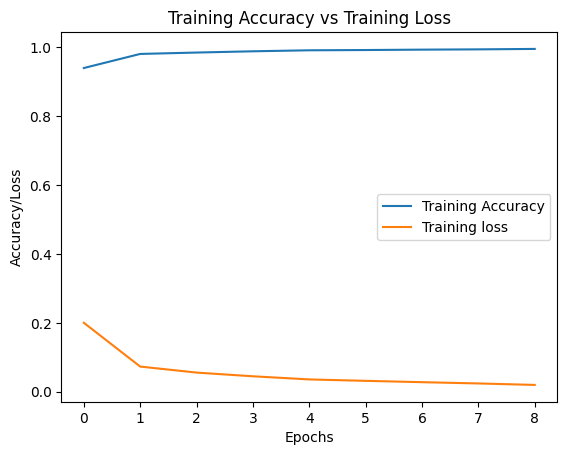

In [12]:
plt.plot(training_acc , label='Training Accuracy')
plt.plot(training_loss , label='Training loss')
plt.title('Training Accuracy vs Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy/Loss')
plt.legend()
plt.show()

In [13]:
test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9920 - loss: 0.0273
Test Accuracy: [0.027288321405649185, 0.9919999837875366]


In [14]:
y_prob = model.predict(x_test[0].reshape(-1,28,28,1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


In [15]:
y_pred = y_prob.argmax(axis=1)

In [16]:
import numpy as np
y_prob = x_test[0].reshape(1,28,28,1)
y_prob = model.predict(y_prob)
y_pred = np.argmax(y_prob, axis =1)
print(f'Probabilities:{y_prob}')
print(f'Predicted class:{y_pred}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Probabilities:[[6.5918803e-12 2.2075435e-09 1.0365115e-09 6.8856152e-09 1.2722641e-12
  1.8714088e-11 1.4177978e-16 9.9999952e-01 1.4247684e-11 4.7120048e-07]]
Predicted class:[7]


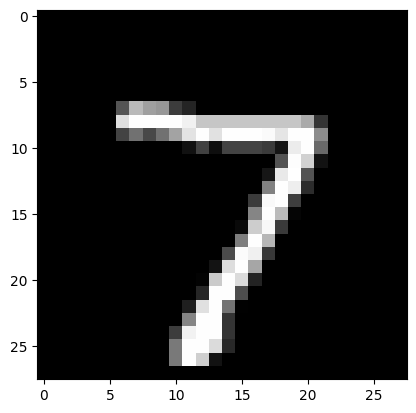

In [17]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


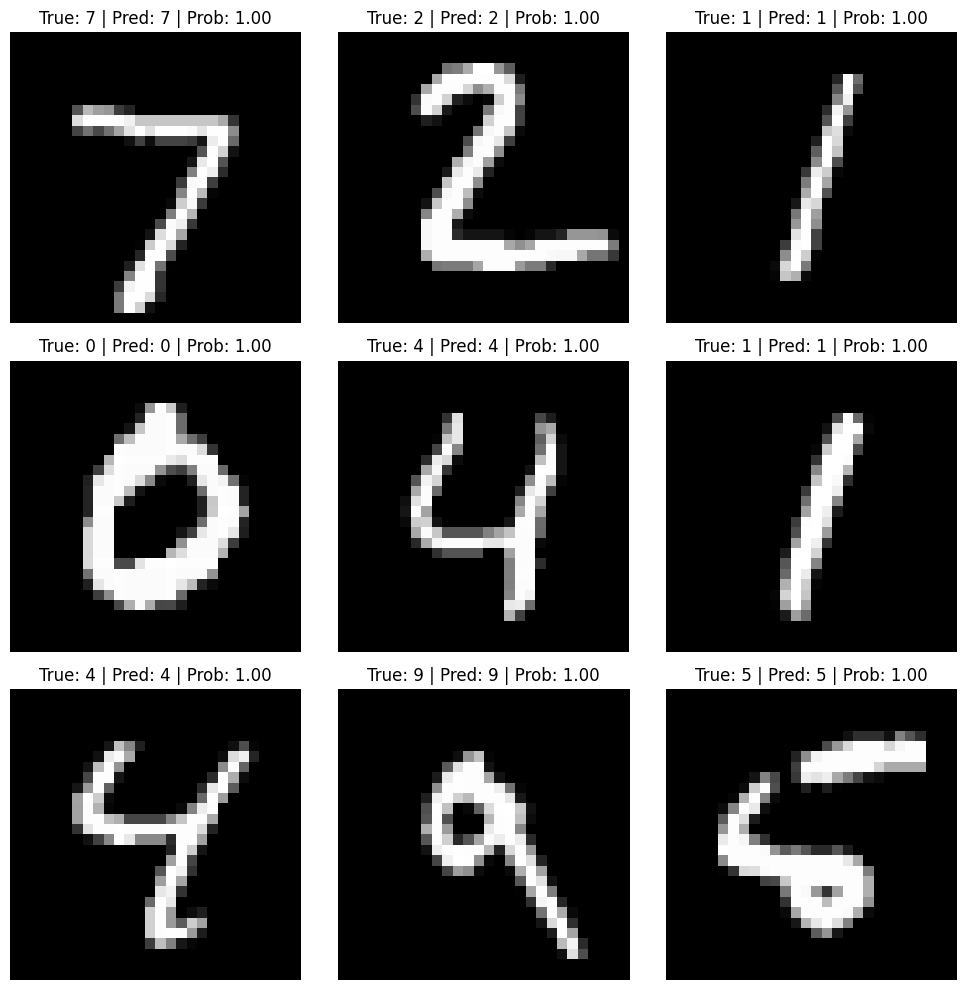

In [18]:
plt.figure(figsize=(10,10))
for i in range(9):
    img = x_test[i].reshape(1, 28, 28, 1)

    prob = model.predict(img)
    pred = np.argmax(prob)
    true = y_test[i]

    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"True: {true} | Pred: {pred} | Prob: {np.max(prob):.2f}")
    plt.axis('off')
plt.tight_layout()
plt.show()


In [20]:
model.save('/content/best_model.h5')